## ОПЖЦ АСОИУ
### РК1. Вариант 91
Чернев Н.А. ИУ5-64Б

### Задача А.
Даны результаты нескольких измерений:
11,6 / 11,2 / 8 / 11,8 / 10,5 / 6,9 / 11 / 10,1 / 12,5 / 13,9 / 9,4
1) Определите доверительную вероятность получения оценки среднего значения
измеряемой величины с точностью е = 0,5
2) Найдите число измерений необходимых для получения среднего значения с точностью
e = 0,25 и доверительной вероятностью Р=0,99


In [1]:
from scipy import stats


data_A = [11.6, 11.2, 8, 11.8, 10.5, 6.9, 11, 10.1, 12.5, 13.9, 9.4]
n = len(data_A)
mean = sum(data_A) / n
std = (sum((x - mean) ** 2 for x in data_A) / (n - 1))**0.5
e1 = 0.5
t = e1 * (n**0.5) / std
p1 = 2 * stats.t.cdf(t, df=n - 1) - 1
print(f"1) Доверительная вероятность: {p1:.06f}")

e2 = 0.25
p_target = 0.99
z = stats.norm.ppf((1 + p_target) / 2)
n_est = int((z * std / e2) ** 2) + 1

n_needed = n_est
while True:
    t_crit = stats.t.ppf((1 + p_target) / 2, n_needed - 1)
    half_width = t_crit * std / (n_needed**0.5)
    if half_width <= e2:
        break
    n_needed += 1

print(f"2) Необходимое число измерений: {n_needed}")

1) Доверительная вероятность: 0.575876
2) Необходимое число измерений: 425


### Задача Б.
В результате наблюдения было получено 100 значений признака, составляющих выборку из
генеральной совокупности. Выполните задания:
1) Найдите выборочное среднее, выборочную дисперсию, среднеквадратическое
отклонение; размах данных; максимум и минимум.
2) Оцените математическое ожидание генеральной совокупности с помощью
доверительного интервала с надёжностями 0,95; 0,99; 0,999.
3) Постройте гистограмму частот.
4) Постройте график плотности треугольного распределения (pdf) с параметрами этой
выборки.
5) Постройте диаграмму размаха данных (блочная диаграмма с ограничителями -
показывает распределение данных по квартилям с выбросами).
6) Примените критерий Пирсона χ2 с уровнем значимости 0,05 для проверки гипотезы о
треугольном распределении генеральной совокупности. Сделайте вывод о принятии
основной гипотезы.

In [2]:
raw_data_B = '''
102 107 99 113 96 108 104 107 100 105 110 106
110 114 100 110 117 109 117 94 116 107 101 122
110 95 122 122 115 102 116 119 116 118 108 115
115 118 106 103 116 110 109 121 123 97 103 97
113 110 119 107 93 104 115 101 121 111 100 93
107 123 109 120 100 111 110 109 106 119 99 122
105 110 123 106 95 107 105 118 114 109 101 114
100 120 107 118 110 99 117 110 104 113 97 113
108 113 105 110 117 116 111 104 115 110 93 110
98 104 110 117 113 114 107 113 107 101 113 107
'''
data_B = [int(x) for x in raw_data_B.split()]
n = len(data_B)
mean = sum(data_B) / n
var = (sum((x - mean) ** 2 for x in data_B) / (n - 1))
std = var**0.5
maximum = max(data_B)
minimum = min(data_B)
data_range = maximum - minimum
print(f"Выборочное среднее: {mean:.6f}")
print(f"Выборочная дисперсия: {var:.6f}")
print(f"Среднеквадратическое отклонение: {std:.6f}")
print(f"Размах: {data_range}")
print(f"Минимум: {minimum}")
print(f"Максимум: {maximum}")

Выборочное среднее: 109.191667
Выборочная дисперсия: 58.139426
Среднеквадратическое отклонение: 7.624921
Размах: 30
Минимум: 93
Максимум: 123


In [3]:
conf_levels = [0.95, 0.99, 0.999]
print('2) Доверительные интервалы для математического ожидания:')
for conf in conf_levels:
    alpha = 1 - conf
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * std / (n**0.5)
    ci = (mean - margin, mean + margin)
    print(f"Надёжность {conf}: {tuple(float(x) for x in ci)}")

2) Доверительные интервалы для математического ожидания:
Надёжность 0.95: (107.81340447541851, 110.56992885791482)
Надёжность 0.99: (107.36954562294893, 111.01378771038439)
Надёжность 0.999: (106.8430547439301, 111.54027858940323)


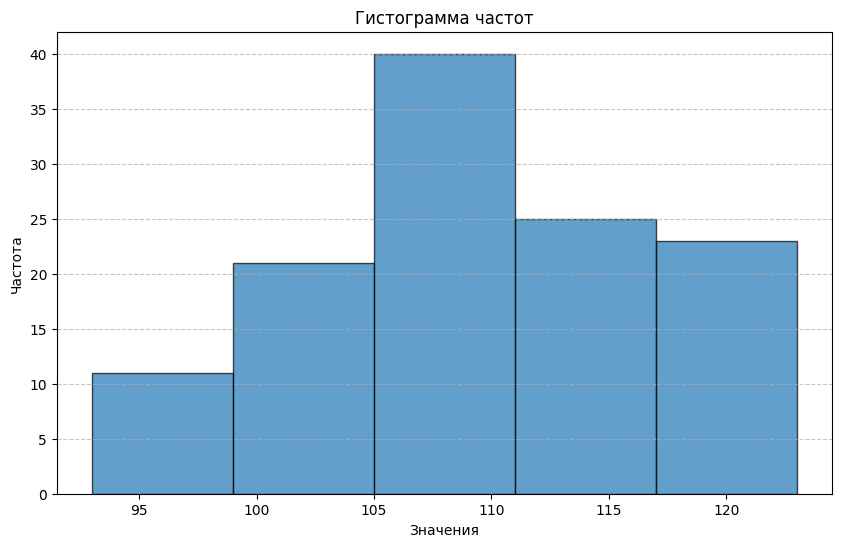

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(data_B, bins=5, edgecolor='black', alpha=0.7)
plt.title('Гистограмма частот')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

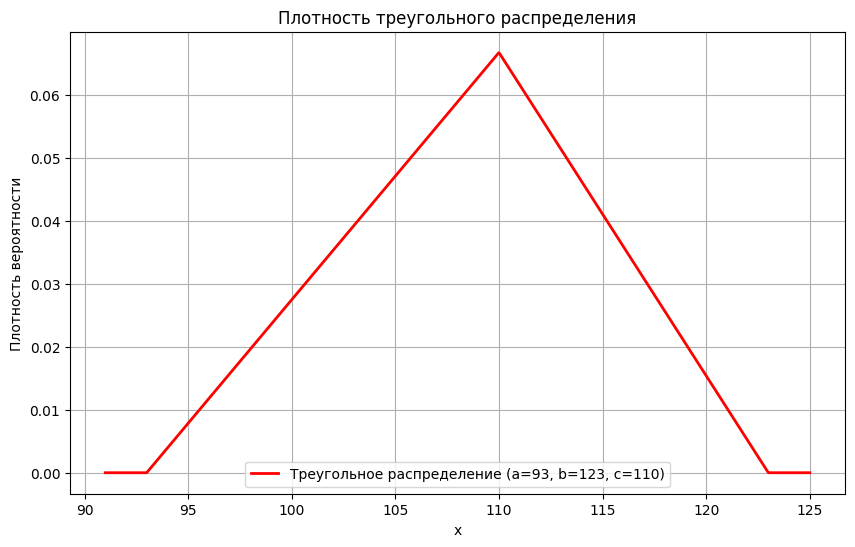

In [5]:
from scipy.stats import mode
import numpy as np


def triangular_pdf(x, a, b, c):
    if a <= x <= c:
        return 2*(x - a) / ((b - a)*(c - a))
    elif c < x <= b:
        return 2*(b - x) / ((b - a)*(b - c))
    else:
        return 0.0


c_mode = mode(data_B, keepdims=True).mode[0]
x_vals = np.linspace(minimum-2, maximum+2, 1000)
y_vals = [triangular_pdf(x, minimum, maximum, c_mode) for x in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'r-', linewidth=2, label=f'Треугольное распределение (a={minimum}, b={maximum}, c={c_mode})')
plt.title('Плотность треугольного распределения')
plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()


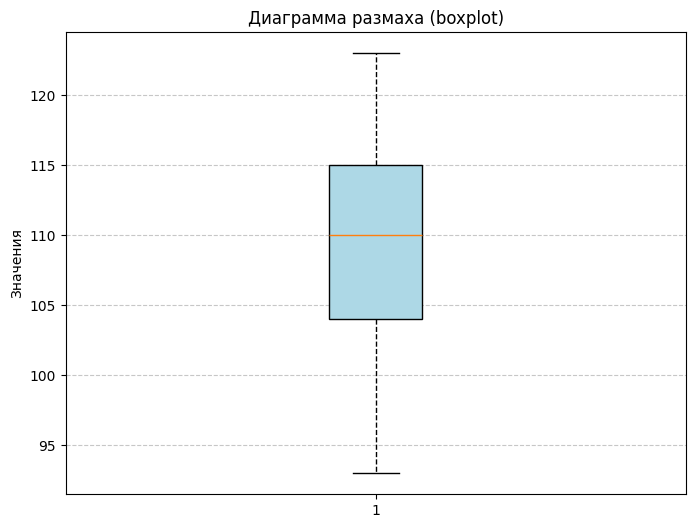

In [6]:
plt.figure(figsize=(8, 6))
plt.boxplot(data_B, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'),
            whiskerprops=dict(color='black', linestyle='--'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title('Диаграмма размаха (boxplot)')
plt.ylabel('Значения')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
k = 8
expected_freq = n / k

def triangular_cdf(x, a, b, c):
    if x < a:
        return 0.0
    elif a <= x <= c:
        return (x - a)**2 / ((b - a)*(c - a))
    elif c < x <= b:
        return 1 - (b - x)**2 / ((b - a)*(b - c))
    else:
        return 1.0

quantiles = [0.0]
for i in range(1, k):
    p = i / k
    low, high = minimum, maximum
    for _ in range(100):
        mid = (low + high) / 2
        if triangular_cdf(mid, minimum, maximum, c_mode) < p:
            low = mid
        else:
            high = mid
    quantiles.append(mid)
quantiles.append(maximum)
quantiles[0] = minimum - 1e-9

observed = np.histogram(data_B, bins=quantiles)[0]

print("6) Критерий Пирсона χ²:")
print(f"Интервалы (границы): {[round(q,2) for q in quantiles]}")
print(f"Наблюдаемые частоты: {observed}")
print(f"Ожидаемая частота в каждом интервале: {expected_freq}")

chi2_stat = sum((obs - expected_freq)**2 / expected_freq for obs in observed)
df_chi2 = k - 1 - 3
critical_value = stats.chi2.ppf(0.95, df_chi2)
p_value = 1 - stats.chi2.cdf(chi2_stat, df_chi2)

print(f"Статистика χ² = {chi2_stat:.4f}")
print(f"Степени свободы: {df_chi2}")
print(f"Критическое значение (α=0.05): {critical_value:.4f}")
print(f"p-value: {p_value:.4f}")

if chi2_stat < critical_value:
    print("Гипотеза о треугольном распределении принимается")
else:
    print("Гипотеза о треугольном распределении отвергается")

6) Критерий Пирсона χ²:
Интервалы (границы): [93.0, 100.98, 104.29, 106.83, 108.97, 110.91, 113.13, 116.02, 123]
Наблюдаемые частоты: [19 13  8 13 19 11 14 23]
Ожидаемая частота в каждом интервале: 15.0
Статистика χ² = 11.3333
Степени свободы: 4
Критическое значение (α=0.05): 9.4877
p-value: 0.0231
Гипотеза о треугольном распределении отвергается


### Задача В.
1) Получите выборку (20 значений) из столбца «среднее время пребывания в системе»
результатов эксперимента моделирования в примере Excel;
2) По полученным данным получите аппроксимацию распределения этого признака
(интерполяция 2го порядка). Постройте график распределения (cdf);
3) По полученному распределению найдите выборочное среднее, выборочную
дисперсию, среднеквадратическое отклонение с доверительной вероятностью 0,95;
4) Сравните распределения этой выборки и данных задачи Б с помощью критерия
Колмогорова-Смирнова. Сделайте вывод о принятии основной гипотезы.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd


raw_data_V = '''
0:06:05
0:06:29
0:05:57
0:06:29
0:06:06
0:05:54
0:05:56
0:05:43
0:06:24
0:06:23
0:06:28
0:06:11
0:06:02
0:05:38
0:05:53
0:05:58
0:06:16
0:06:05
0:06:40
0:06:37
'''
time = [[int(y) for y in x.split(':')] for x in raw_data_V.split()]
data_V = [x[0] * 3600 + x[1] * 60 + x[2] for x in time]
n = len(data_V)
print(f"Объём выборки: {n}")
print(f"Данные в секундах: {data_V}")

Объём выборки: 20
Данные в секундах: [365, 389, 357, 389, 366, 354, 356, 343, 384, 383, 388, 371, 362, 338, 353, 358, 376, 365, 400, 397]


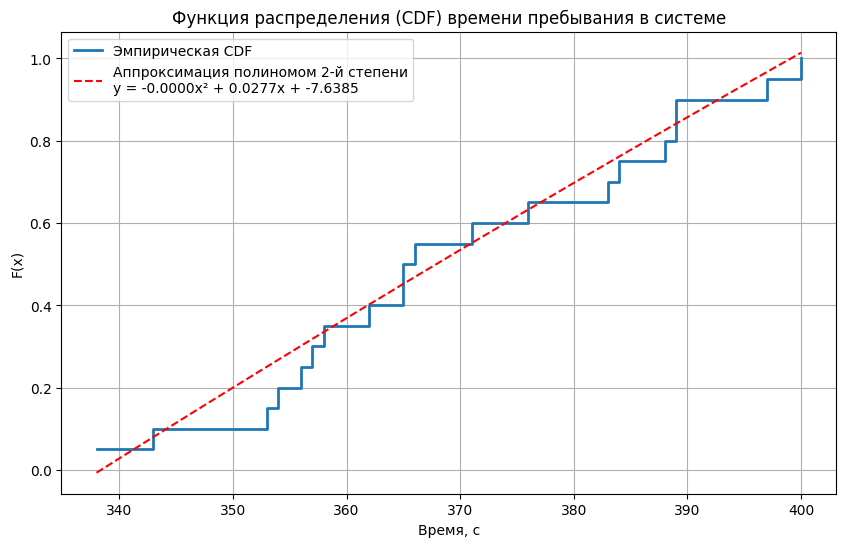

In [9]:
sorted_data = sorted(data_V)
ecdf_y = np.arange(1, n+1) / n

coeffs = np.polyfit(sorted_data, ecdf_y, 2)
poly = np.poly1d(coeffs)

x_smooth = np.linspace(sorted_data[0], sorted_data[-1], 200)
y_smooth = poly(x_smooth)

plt.figure(figsize=(10, 6))
plt.step(sorted_data, ecdf_y, where='post', label='Эмпирическая CDF', linewidth=2)
plt.plot(x_smooth, y_smooth, 'r--', label=f'Аппроксимация полиномом 2-й степени\ny = {coeffs[0]:.4f}x² + {coeffs[1]:.4f}x + {coeffs[2]:.4f}')
plt.xlabel('Время, с')
plt.ylabel('F(x)')
plt.title('Функция распределения (CDF) времени пребывания в системе')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
mean_V = np.mean(data_V)
var_V = np.var(data_V, ddof=1)
std_V = np.std(data_V, ddof=1)

print(f"Выборочное среднее: {mean_V:.4f} с")
print(f"Выборочная дисперсия: {var_V:.4f}")
print(f"СКО: {std_V:.4f} с")

conf_level = 0.95
alpha = 1 - conf_level
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
margin = t_crit * std_V / np.sqrt(n)
ci = (mean_V - margin, mean_V + margin)
print(f"\nДоверительный интервал для среднего (P={conf_level}): ({ci[0]:.4f}, {ci[1]:.4f}) с")

Выборочное среднее: 369.7000 с
Выборочная дисперсия: 316.4316
СКО: 17.7885 с

Доверительный интервал для среднего (P=0.95): (361.3747, 378.0253) с


Статистика KS: 1.0000
p-value: 0.000000
Нулевая гипотеза отвергается (p < 0.05).


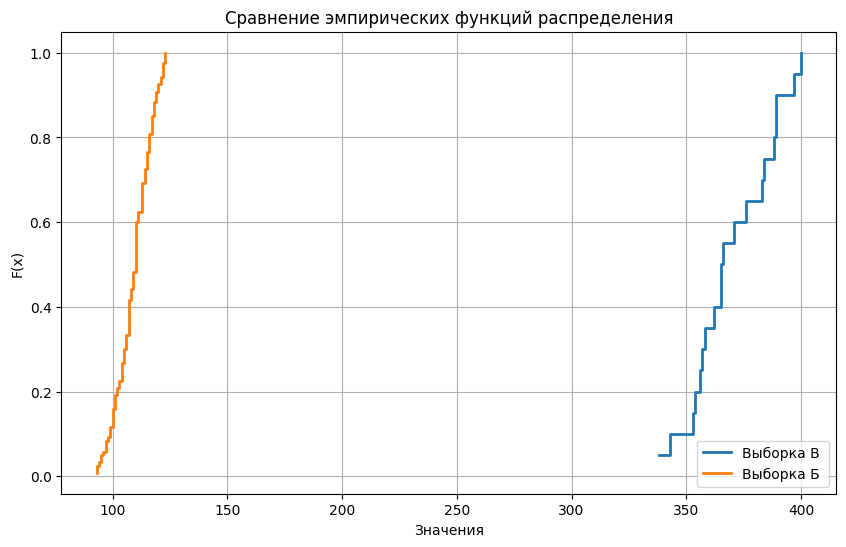

In [11]:
ks_stat, p_value = stats.ks_2samp(data_V, data_B)
print(f"Статистика KS: {ks_stat:.4f}")
print(f"p-value: {p_value:.6f}")
alpha_ks = 0.05
if p_value < alpha_ks:
    print(f"Нулевая гипотеза отвергается (p < {alpha_ks}).")
else:
    print(f"Нулевая гипотеза подтверждается")

# Дополнительно: можно построить обе эмпирические CDF на одном графике
plt.figure(figsize=(10, 6))
plt.step(np.sort(data_V), np.arange(1, n+1)/n, where='post', label='Выборка В', linewidth=2)
plt.step(np.sort(data_B), np.arange(1, len(data_B)+1)/len(data_B), where='post', label='Выборка Б ', linewidth=2)
plt.xlabel('Значения')
plt.ylabel('F(x)')
plt.title('Сравнение эмпирических функций распределения')
plt.legend()
plt.grid(True)
plt.show()